In [5]:
import arviz as az
import pandas as pd
import numpy as np
import pymc as pm
import bambi as bmb
import xarray as xr
import random
import os
#%load_ext rpy2.ipython

import seaborn as sns
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

az.style.use("arviz-doc")
sns.set_context("paper")
import matplotlib as mpl
scale = 0.35
d = dict([(k, v*scale) for (k, v) in sns.plotting_context('paper').items()])
d['figure.figsize'] = [1.8, 1.3]
mpl.rcParams.update(d)

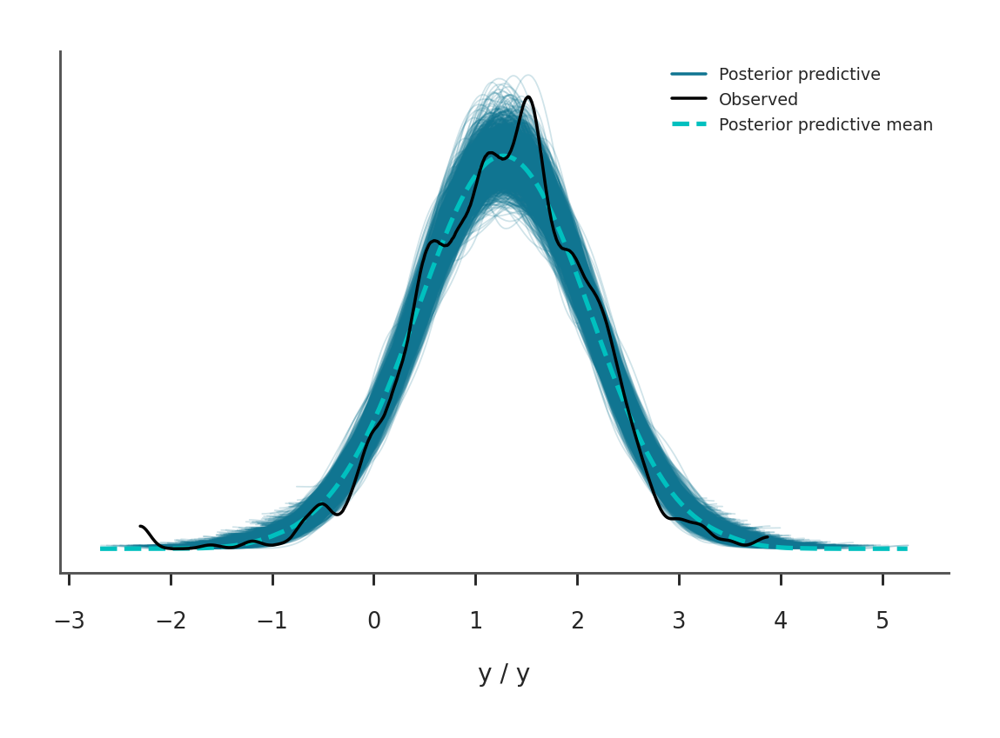

In [6]:
data = az.load_arviz_data('radon')
az.plot_ppc(data, data_pairs={"y":"y"}) ;

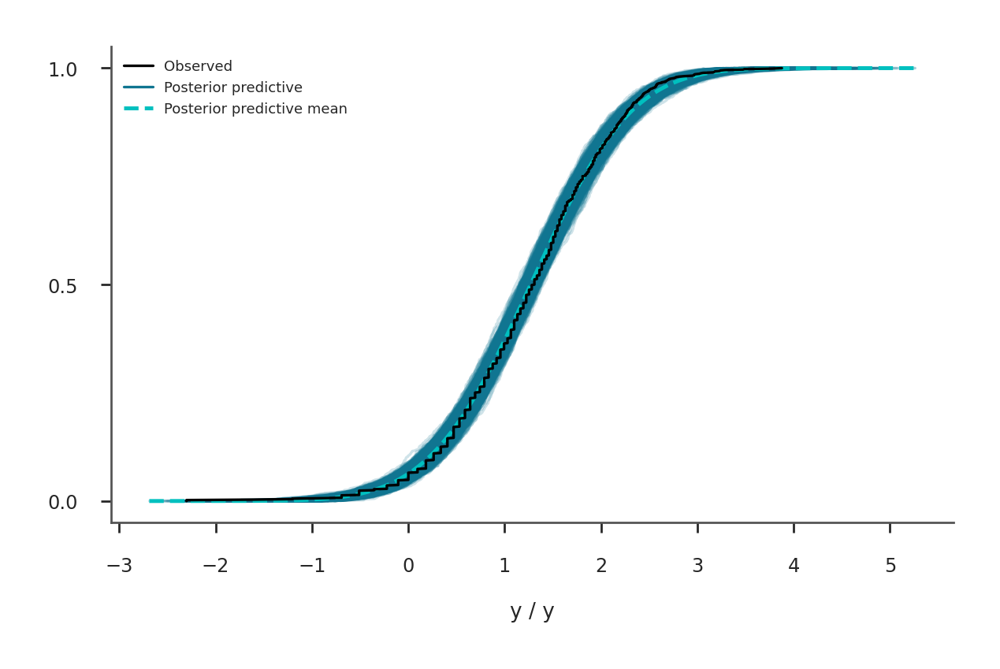

In [352]:
az.plot_ppc(data, kind='cumulative') ;

In [353]:
data

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data
	> constant_data

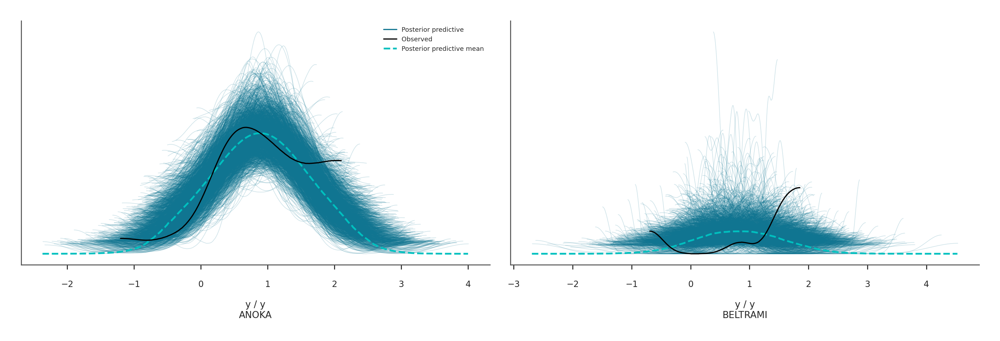

In [354]:
obs_county = data.posterior["County"][data.constant_data["county_idx"]]
d = data.assign_coords(obs_id=obs_county, groups="observed_vars")
az.plot_ppc(d, coords={'obs_id': ['ANOKA', 'BELTRAMI']}, flatten=[]) ;

Filter based on callability and remove X chromosome and adjust for missing coverage by extrapolating

In [13]:
df = pd.read_csv('Reduced_Ne_Pi_recomb.csv')
df = df[df['freq_mean']>0.7]
df = df[df['chr']!='chrX']
df['corrected_pi'] = df['PI']*df['freq_mean']

# My version

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


data = df[['full_species', 'NE_MEDIAN', 'corrected_pi', 'cm_per_mb']].copy()
#data["full_species"] = data.full_species.astype("category")

data['z_ne'] = (data.NE_MEDIAN - data.NE_MEDIAN.mean()) / data.NE_MEDIAN.std()

gr = data.groupby('full_species')
data[['z_pi', 'z_cm_per_mb']] = gr[['corrected_pi', 'cm_per_mb']].transform(lambda sr: (sr - sr.mean()) / sr.std())
data.head()

,full_species,NE_MEDIAN,corrected_pi,cm_per_mb,z_ne,z_pi,z_cm_per_mb
2,Allenopithecus_nigroviridis,48795.239046,0.001466,0.032423,-0.330025,0.035514,-0.820631
3,Allenopithecus_nigroviridis,48795.239046,0.001466,1.734505,-0.330025,0.036663,0.266051
4,Allenopithecus_nigroviridis,48795.239046,0.002012,1.056430,-0.330025,0.849468,-0.166861
5,Allenopithecus_nigroviridis,48795.239046,0.001379,0.420616,-0.330025,-0.093303,-0.572792
6,Allenopithecus_nigroviridis,48795.239046,0.001342,1.470184,-0.330025,-0.149338,0.097297


In [328]:
species = le.fit_transform(df['full_species'])
unique_species = pd.unique(le.inverse_transform(species))
ne = data[['full_species', 'z_ne']].drop_duplicates().z_ne
pi = data['z_pi'].values
recombinationrate = data['z_cm_per_mb'].values

In [332]:
window_y_values = pi
window_x_values = recombinationrate
global_group_names = unique_species
global_group_indices = species
global_group_values = ne

assert len(global_group_names) == len(global_group_values)
assert len(window_y_values) == len(window_x_values)
assert len(window_x_values) == len(global_group_indices)

In [333]:
model = pm.Model(coords = {"global_group": global_group_names,
                           "obs_id": np.arange(len(window_x_values))})
non_centered = True

with model:
    # data
    window_dependent = pm.ConstantData('window_dependent', window_x_values, dims='obs_id')
    window_independent = pm.ConstantData('window_independent', window_y_values, dims='obs_id')
    global_group = pm.ConstantData('global_group', global_group_indices, dims='obs_id')
    global_dependent =  pm.ConstantData('global_dependent', global_group_values, dims='global_group')

    # hyperprior on window_independent ~ window_dependent intercept prior
    hyp_inter_of_inter = pm.Normal("hyp_inter_of_inter", mu=0, sigma=1)
    hyp_inter_of_slope = pm.Normal("hyp_inter_of_slope", mu=0, sigma=1)
    
    # hyperprior on window_independent ~ window_dependent slope prior
    hyp_slope_of_inter = pm.Normal("hyp_slope_of_inter", mu=0, sigma=1)
    hyp_slope_of_slope = pm.Normal("hyp_slope_of_slope", mu=0, sigma=1)

    # prior on residual variation on global_group intercepts
    group_inter_residual = pm.Normal("group_inter_residual", 0, sigma=1, dims="global_group")
    
    # prior on residual variation on global_group slopes
    group_slope_residual = pm.Normal("group_slope_residual", 0, sigma=1, dims="global_group")

    # prior on window_independent ~ window_dependent intercept for each global_group
    mu_inter = hyp_inter_of_inter + hyp_inter_of_slope * global_dependent
    sigma_inter = pm.Exponential("sigma_inter", 1)
    group_inter = pm.Deterministic("group_inter", mu_inter + group_inter_residual * sigma_inter, dims="global_group")

    # prior on window_independent ~ window_dependent slope for each global_group
    mu_slope = hyp_slope_of_inter + hyp_slope_of_slope * global_dependent
    sigma_slope = pm.Exponential("sigma_slope", 1)
    group_slope = pm.Deterministic("group_slope", mu_slope + group_slope_residual * sigma_slope, dims="global_group")
        
    # prior window_independent ~ window_dependent slope for each global_group
    mu_window_independent = group_inter[global_group] + group_slope[global_group] * window_dependent
    sigma_window_independent = pm.Exponential("sigma_window_independent", 0.01)

    # prior
    indep = pm.Normal("Pi", mu=mu_window_independent, sigma=sigma_window_independent, observed=window_dependent, dims="obs_id")

In [334]:
with model:
    idata = pm.sample_prior_predictive(samples=200)

Sampling: [Pi, group_inter_residual, group_slope_residual, hyp_inter_of_inter, hyp_inter_of_slope, hyp_slope_of_inter, hyp_slope_of_slope, sigma_inter, sigma_slope, sigma_window_independent]


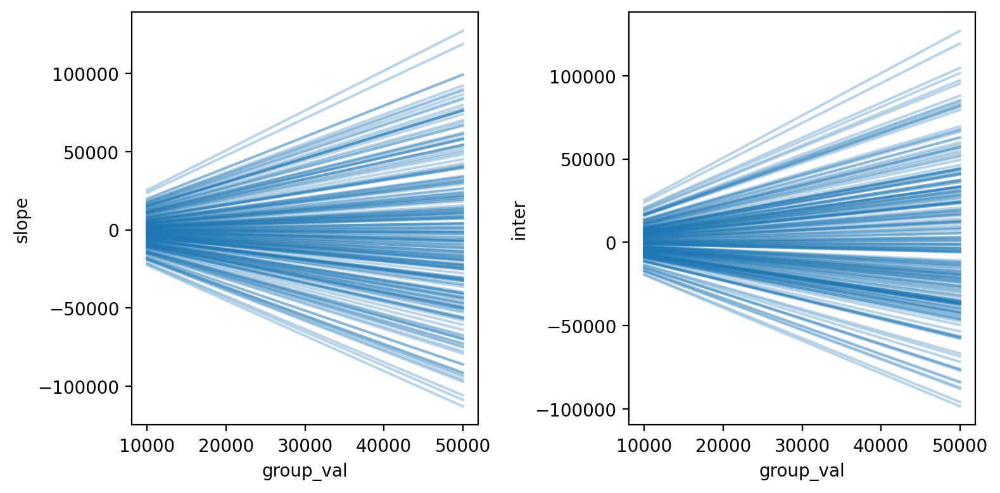

In [335]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

group_val = xr.DataArray(np.linspace(10000, 50000, 200), dims=["plot_dim"])
prior = idata.prior

slope = prior["hyp_slope_of_inter"] + prior["hyp_slope_of_slope"] * group_val
ax1.plot(group_val, slope.stack(sample=("chain", "draw")), c="C0", alpha=0.3)
ax1.set_xlabel("group_val")
ax1.set_ylabel("slope") 
inter = prior["hyp_inter_of_inter"] + prior["hyp_slope_of_inter"] * group_val
ax2.plot(group_val, inter.stack(sample=("chain", "draw")), c="C0", alpha=0.3)
ax2.set_xlabel("group_val")
ax2.set_ylabel("inter")
plt.tight_layout()

# Bjarkes version

Standardize and center so priors can be mu = 0 and sigma = 1

This is done by taking the species specific mean 

In [15]:
grouped_df = df.groupby('full_species')

# Calculate Mean and Standard Deviation
means = pd.DataFrame()
means[['mean_pi_species','mean_cm_per_mb_species']] = grouped_df[['corrected_pi', 'cm_per_mb']].mean()
means[['sd_pi_species','sd_cm_per_mb_species']] = grouped_df[['corrected_pi', 'cm_per_mb']].std()
means['primate_mean_ne'] = df['NE_MEDIAN'].mean()
means['primate_sd_ne'] = df['NE_MEDIAN'].std()
means = means[['mean_pi_species','mean_cm_per_mb_species', 'sd_pi_species','sd_cm_per_mb_species', 'primate_mean_ne', 'primate_sd_ne']]

In [16]:
# Merge dataframes on the 'full_species' column
merged_df = pd.merge(df, means, on='full_species')

# Reset the index to remove the default index column
merged_df = merged_df.reset_index(drop=True)
merged_df.head()

,Unnamed: 0,genus,species,full_species,MEAN,MEDIAN,NE_MEAN,NE_MEDIAN,freq_mean,cm_per_mb,chr,PI,corrected_pi,mean_pi_species,mean_cm_per_mb_species,sd_pi_species,sd_cm_per_mb_species,primate_mean_ne,primate_sd_ne
0,2,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.809708,0.032423,chr1,0.001810,0.001466,0.001442,1.317787,0.000671,1.566311,70106.64657,64575.160355
1,3,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.716477,1.734505,chr1,0.002047,0.001466,0.001442,1.317787,0.000671,1.566311,70106.64657,64575.160355
2,4,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.784308,1.056430,chr1,0.002565,0.002012,0.001442,1.317787,0.000671,1.566311,70106.64657,64575.160355
3,5,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.747552,0.420616,chr1,0.001845,0.001379,0.001442,1.317787,0.000671,1.566311,70106.64657,64575.160355
4,6,Allenopithecus,nigroviridis,Allenopithecus_nigroviridis,8.357479e-09,8.297569e-09,52454.392022,48795.239046,0.783023,1.470184,chr1,0.001713,0.001342,0.001442,1.317787,0.000671,1.566311,70106.64657,64575.160355


In [17]:
merged_df['z_pi'] = (merged_df['corrected_pi']-merged_df['mean_pi_species'])/merged_df['sd_pi_species']
merged_df['z_cm_per_mb'] = (merged_df['cm_per_mb']-merged_df['mean_cm_per_mb_species'])/merged_df['sd_cm_per_mb_species']
merged_df['z_ne'] = (merged_df['NE_MEDIAN']-merged_df['primate_mean_ne'])/merged_df['primate_sd_ne']
z_df = merged_df[['full_species','NE_MEDIAN','z_pi', 'z_cm_per_mb', 'z_ne']]
z_df.head()

,full_species,NE_MEDIAN,z_pi,z_cm_per_mb,z_ne
0,Allenopithecus_nigroviridis,48795.239046,0.035514,-0.820631,-0.330025
1,Allenopithecus_nigroviridis,48795.239046,0.036663,0.266051,-0.330025
2,Allenopithecus_nigroviridis,48795.239046,0.849468,-0.166861,-0.330025
3,Allenopithecus_nigroviridis,48795.239046,-0.093303,-0.572792,-0.330025
4,Allenopithecus_nigroviridis,48795.239046,-0.149338,0.097297,-0.330025


In [18]:
unique_Species = z_df['full_species'].unique()
species_lookup = dict(zip(unique_Species, range(len(unique_Species))))
Ne =  (pd.DataFrame([z_df['full_species'], z_df['z_ne']]).transpose()).drop_duplicates()
pi = z_df['z_pi'].values
recombinationrate = z_df['z_cm_per_mb'].values
species = z_df['full_species'].replace(species_lookup).values

In [21]:
hierarchical_model = pm.Model(coords = {"Species": unique_Species, 
                                        "obs_id": np.arange(len(recombinationrate))})
non_centered = True

with hierarchical_model:
    # data
    recomb = pm.ConstantData('recomb', recombinationrate, dims = 'obs_id')
    pi = pm.ConstantData('pi', pi, dims = 'obs_id')
    sp = pm.ConstantData('sp',species, dims = 'obs_id')
    Ne =  pm.ConstantData('Ne', Ne['z_ne'], dims = 'Species')

    # hyperprior on prior intercept
    g0 = pm.Normal("g0", mu=0, sigma=1)
    g1 = pm.Normal("g1", mu=0, sigma=1)
    # hyperprior prior sl
    h0 = pm.Normal("h0", mu=0, sigma=1)
    h1 = pm.Normal("h1", mu=0, sigma=1)

    # prior on intercept
    mu_a = g0 + g1 * Ne
    sigma_a = pm.Exponential("sigma_a", 1)
    a_offset = pm.Normal("a_offset", 0, sigma=1, dims="Species") # prior on intercept variation across species
    a = pm.Deterministic("a", mu_a + a_offset * sigma_a, dims="Species") # species-specific intercepts
    # prior on slope
    mu_b = h0 + h1 * Ne
    sigma_b = pm.Exponential("sigma_b", 1)
    b_offset = pm.Normal("b_offset", 0, sigma=1, dims="Species") # prior on slope variation across species
    b = pm.Deterministic("b", mu_b + b_offset * sigma_b, dims="Species") # species-specific slopes
        
    # species specific prior parameters:
    y = a[sp] + b[sp] * recomb
    sigma = pm.Exponential("sigma", 0.01)

    # prior
    Pi = pm.Normal("Pi", mu=y, sigma=sigma, observed=pi, dims="obs_id")

In [34]:
%%capture
fig, ax = plt.subplots()
g = pm.model_to_graphviz(hierarchical_model)
g.graph_attr.update(size="10,10")

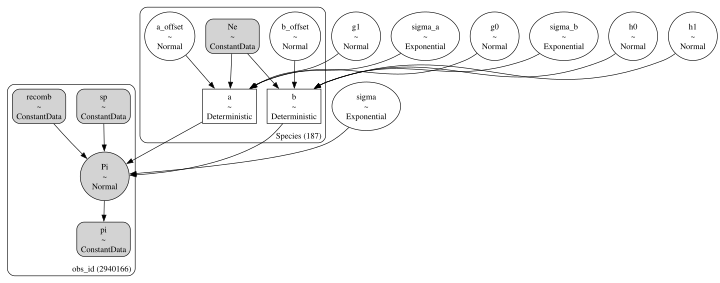

In [36]:
g

In [ ]:
with hierarchical_model:
    idata = pm.sample_prior_predictive(samples=200)

<Axes: xlabel='Pi / Pi'>

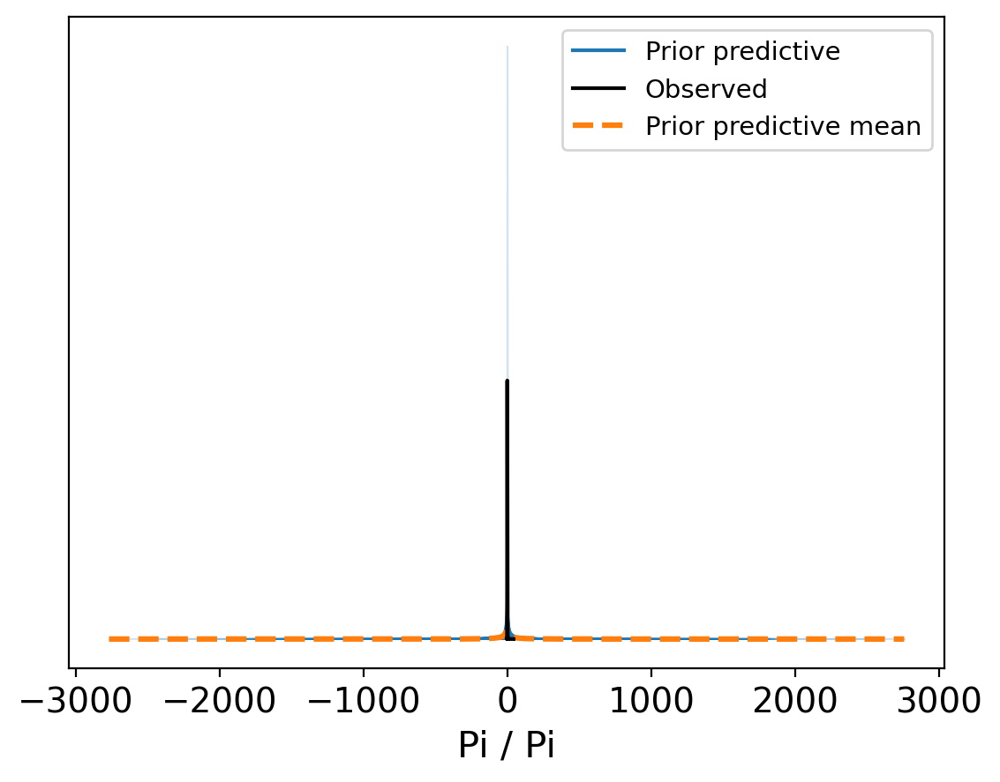

In [15]:
az.plot_ppc(idata, group='prior') ;

In [ ]:
az.plot_ppc(idata, group='prior', kind='cumulative') ;

In [ ]:
obs_county = data.posterior["County"][data.constant_data["county_idx"]]
data = data.assign_coords(obs_id=obs_county, groups="observed_vars")
az.plot_ppc(data, coords={'obs_id': ['ANOKA', 'BELTRAMI']}, flatten=[])

In [17]:
trace_file = 'hierarchical_model_18_12_2023.nc'
if os.path.exists(trace_file):
    with hierarchical_model:
         hierarchical_model_idata = az.from_netcdf(trace_file)
else:
    with hierarchical_model:
        hierarchical_model_idata = pm.sample(1000,
                                             target_accept=0.95, return_inferencedata=True,
                                 progressbar=True, cores=8, chains=8)
        hierarchical_model_idata.to_netcdf(trace_file)

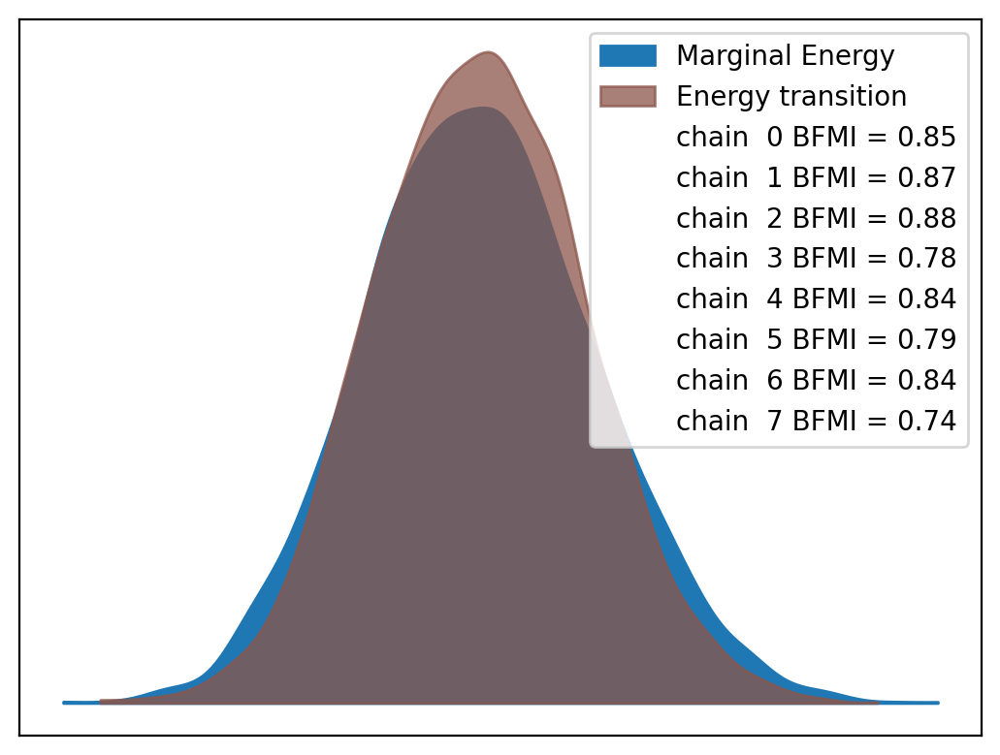

In [18]:
az.plot_energy(hierarchical_model_idata);

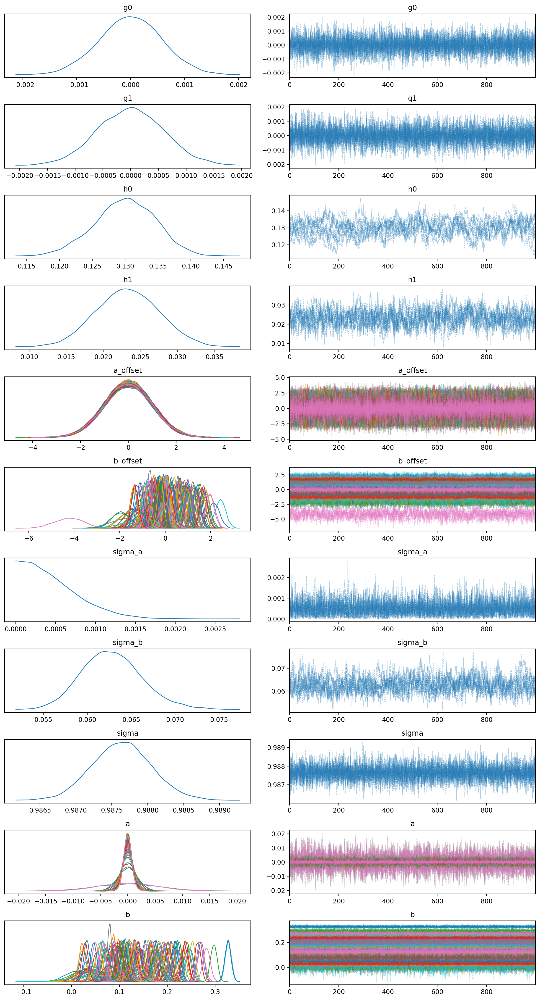

In [19]:
az.plot_trace(hierarchical_model_idata, combined=True)
plt.tight_layout()

In [20]:
hierarchical_model_idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [21]:
hierarchical_model_idata.posterior.to_dataframe()

g0            g1        h0  \
chain draw Species                                                         
0     0    Allenopithecus_nigroviridis  0.000431  3.367056e-07  0.134112   
           Allochrocebus_lhoesti        0.000431  3.367056e-07  0.134112   
           Allochrocebus_preussi        0.000431  3.367056e-07  0.134112   
           Allochrocebus_solatus        0.000431  3.367056e-07  0.134112   
           Alouatta_belzebul            0.000431  3.367056e-07  0.134112   
...                                          ...           ...       ...   
7     999  Trachypithecus_melamera     -0.000608  1.015017e-04  0.137349   
           Trachypithecus_phayrei      -0.000608  1.015017e-04  0.137349   
           Trachypithecus_pileatus     -0.000608  1.015017e-04  0.137349   
           Varecia_rubra               -0.000608  1.015017e-04  0.137349   
           Varecia_variegata           -0.000608  1.015017e-04  0.137349   

                                              h1  a_offset  b_offset  \
chain draw Species                                                     
0     0    Allenopithecus_nigroviridis  0.016744  1.230759 -0.037840   
           Allochrocebus_lhoesti        0.016744  0.920322 -0.352860   
           Allochrocebus_preussi        0.016744  1.043132 -0.550745   
           Allochrocebus_solatus        0.016744 -1.758868 -0.726982   
           Alouatta_belzebul            0.016744  0.661122  0.164182   
...                                          ...       ...       ...   
7     999  Trachypithecus_melamera      0.027362  0.105532 -0.230695   
           Trachypithecus_phayrei       0.027362  0.552308 -1.288621   
           Trachypithecus_pileatus      0.027362 -0.295904 -0.719518   
           Varecia_rubra                0.027362 -0.294301 -1.003085   
           Varecia_variegata            0.027362  1.034759  0.125312   

                                         sigma_a   sigma_b     sigma  \
chain draw Species                                                     
0     0    Allenopithecus_nigroviridis  0.001623  0.062407  0.988322   
           Allochrocebus_lhoesti        0.001623  0.062407  0.988322   
           Allochrocebus_preussi        0.001623  0.062407  0.988322   
           Allochrocebus_solatus        0.001623  0.062407  0.988322   
           Alouatta_belzebul            0.001623  0.062407  0.988322   
...                                          ...       ...       ...   
7     999  Trachypithecus_melamera      0.000473  0.063950  0.987356   
           Trachypithecus_phayrei       0.000473  0.063950  0.987356   
           Trachypithecus_pileatus      0.000473  0.063950  0.987356   
           Varecia_rubra                0.000473  0.063950  0.987356   
           Varecia_variegata            0.000473  0.063950  0.987356   

                                               a         b  
chain draw Species                                          
0     0    Allenopithecus_nigroviridis  0.002428  0.126224  
           Allochrocebus_lhoesti        0.001925  0.115503  
           Allochrocebus_preussi        0.002124  0.105326  
           Allochrocebus_solatus       -0.002423  0.096889  
           Alouatta_belzebul            0.001504  0.140329  
...                                          ...       ...  
7     999  Trachypithecus_melamera     -0.000613  0.107883  
           Trachypithecus_phayrei      -0.000424  0.034218  
           Trachypithecus_pileatus     -0.000798  0.077991  
           Varecia_rubra               -0.000791  0.061399  
           Varecia_variegata           -0.000127  0.143291  

[1496000 rows x 11 columns]

In [22]:
t = az.extract(hierarchical_model_idata, num_samples=20)

In [23]:
t

<xarray.Dataset>
Dimensions:   (sample: 20, Species: 187)
Coordinates:
  * Species   (Species) <U28 'Allenopithecus_nigroviridis' ... 'Varecia_varie...
  * sample    (sample) object MultiIndex
  * chain     (sample) int64 5 0 2 1 3 5 2 5 2 1 5 4 5 4 4 6 1 0 4 5
  * draw      (sample) int64 246 984 880 593 125 224 ... 248 593 726 942 719 205
Data variables:
    g0        (sample) float64 0.0002206 -0.00042 ... -0.0003637 -0.001004
    g1        (sample) float64 0.0003212 0.0005986 ... -0.0008953 0.0002829
    h0        (sample) float64 0.1231 0.1324 0.1399 ... 0.1261 0.1273 0.1218
    h1        (sample) float64 0.02593 0.02756 0.0182 ... 0.02836 0.02486
    a_offset  (Species, sample) float64 -0.02565 0.8341 0.971 ... 0.04097 1.328
    b_offset  (Species, sample) float64 0.2003 -0.1105 ... 0.2224 -0.3024
    sigma_a   (sample) float64 0.0006057 0.0004154 ... 0.0003949 0.0006077
    sigma_b   (sample) float64 0.06194 0.05804 0.06245 ... 0.06191 0.05863
    sigma     (sample) float64 0.9889 0.9879 0.9876 ... 0.9877 0.9875 0.9879
    a         (Species, sample) float64 9.903e-05 -0.0002711 ... -0.0002188
    b         (Species, sample) float64 0.127 0.1169 0.1167 ... 0.1389 0.1022
Attributes:
    created_at:                 2024-02-21T02:12:14.209178
    arviz_version:              0.16.1
    inference_library:          pymc
    inference_library_version:  5.10.0
    sampling_time:              11523.772596120834
    tuning_steps:               1000

In [24]:
merged_df[['full_species', 'NE_MEAN']].drop_duplicates().set_index('full_species').loc[t.Species, 'NE_MEAN']

full_species
Allenopithecus_nigroviridis     52454.392022
Allochrocebus_lhoesti           91522.612916
Allochrocebus_preussi           98961.872671
Allochrocebus_solatus          110522.354754
Alouatta_belzebul               59405.700850
                                   ...      
Trachypithecus_melamera         45550.929003
Trachypithecus_phayrei          20253.268312
Trachypithecus_pileatus         42453.240463
Varecia_rubra                   45401.300726
Varecia_variegata               71894.996141
Name: NE_MEAN, Length: 187, dtype: float64

<Axes: xlabel='x', ylabel='y'>

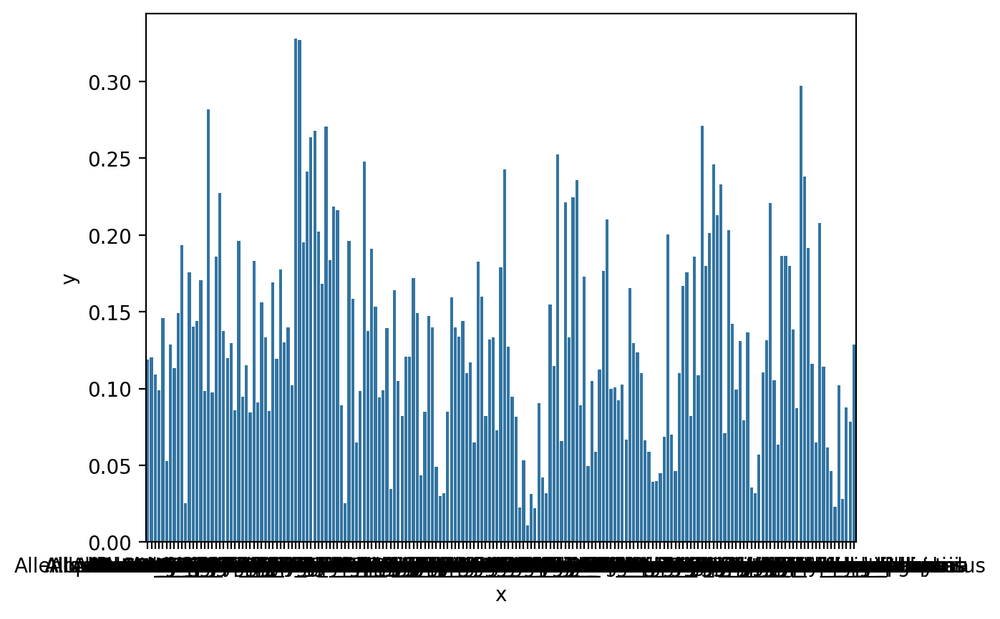

In [25]:
import seaborn as sns
d = hierarchical_model_idata.posterior.mean(dim=['chain', 'draw'])
sns.barplot(data=pd.DataFrame(dict(x=d.Species, y=d.b)), x='x', y='y')

# Log scaled Ne model

In [26]:
#TAKING THE LOG TO BOTH NE AND CM_PER_MB
means_log = pd.DataFrame()
# Step 2: Calculate Mean and Standard Deviation
means_log['mean_pi_species'] = grouped_df['corrected_pi'].mean()
means_log['mean_cm_per_mb_species'] = np.log10(grouped_df['cm_per_mb'].mean())
means_log['sd_pi_species'] = grouped_df['corrected_pi'].std()
means_log['sd_cm_per_mb_species'] = np.log10(grouped_df['cm_per_mb'].std())
means_log['primate_mean_ne'] = np.log10(df['NE_MEDIAN'].mean())
means_log['primate_sd_ne'] = np.log10(df['NE_MEDIAN'].std())


means_log = means_log[['mean_pi_species','mean_cm_per_mb_species', 'sd_pi_species','sd_cm_per_mb_species', 'primate_mean_ne', 'primate_sd_ne']]

In [27]:
# Merge dataframes on the 'full_species' column
merged_log_df = pd.merge(df, means_log, on='full_species')

# Reset the index to remove the default index column
merged_log_df = merged_log_df.reset_index(drop=True).dropna()
#remove real zeros
merged_log_df = merged_log_df[merged_log_df['cm_per_mb']!=0]


In [28]:
merged_log_df['z_pi'] = (merged_log_df['corrected_pi']-merged_log_df['mean_pi_species'])/merged_log_df['sd_pi_species']
merged_log_df['z_cm_per_mb'] = (np.log10(merged_log_df['cm_per_mb'])-merged_log_df['mean_cm_per_mb_species'])/merged_log_df['sd_cm_per_mb_species']
merged_log_df['z_ne'] = (np.log10(merged_log_df['NE_MEDIAN'])-merged_log_df['primate_mean_ne'])/merged_log_df['primate_sd_ne']
z_log_df = merged_log_df[['full_species','NE_MEDIAN','z_pi', 'z_cm_per_mb', 'z_ne']]

In [29]:
z_log_df

,full_species,NE_MEDIAN,z_pi,z_cm_per_mb,z_ne
0,Allenopithecus_nigroviridis,48795.239046,0.035514,-8.256388,-0.032719
1,Allenopithecus_nigroviridis,48795.239046,0.036663,0.612334,-0.032719
2,Allenopithecus_nigroviridis,48795.239046,0.849468,-0.492639,-0.032719
3,Allenopithecus_nigroviridis,48795.239046,-0.093303,-2.544971,-0.032719
4,Allenopithecus_nigroviridis,48795.239046,-0.149338,0.243879,-0.032719
...,...,...,...,...,...
2940161,Varecia_variegata,65217.078027,0.638573,-0.200048,-0.006528
2940162,Varecia_variegata,65217.078027,0.415710,-4.242678,-0.006528
2940163,Varecia_variegata,65217.078027,0.885051,-3.640185,-0.006528
2940164,Varecia_variegata,65217.078027,0.358877,-4.793674,-0.006528


In [30]:
unique_Species_log = z_log_df['full_species'].unique()
species_lookup_log = dict(zip(unique_Species_log, range(len(unique_Species_log))))
Ne_log =  (pd.DataFrame([z_log_df['full_species'], z_log_df['z_ne']]).transpose()).drop_duplicates()
pi_log = z_log_df['z_pi'].values
recombinationrate_log = z_log_df['z_cm_per_mb'].values
species_log = z_log_df['full_species'].replace(species_lookup_log).values


In [31]:
Ne_log 

,full_species,z_ne
0,Allenopithecus_nigroviridis,-0.032719
23342,Allochrocebus_lhoesti,0.015532
46984,Allochrocebus_preussi,0.024187
70575,Allochrocebus_solatus,0.033431
93138,Alouatta_belzebul,-0.022621
...,...,...
2872164,Trachypithecus_melamera,-0.061733
2889185,Trachypithecus_phayrei,-0.107995
2911924,Trachypithecus_pileatus,-0.05385
2933570,Varecia_rubra,-0.045717


In [32]:
hierarchical_log_scaled_ne_cmpermb_model = pm.Model(coords = {"Species": unique_Species_log, 
                                        "obs_id": np.arange(len(recombinationrate_log))})
non_centered = True

In [33]:
with hierarchical_log_scaled_ne_cmpermb_model:
    # data
    recomb = pm.ConstantData('recomb', recombinationrate_log, dims = 'obs_id')
    pi = pm.ConstantData('pi', pi_log, dims = 'obs_id')
    sp = pm.ConstantData('sp',species_log, dims = 'obs_id')
    Ne =  pm.ConstantData('Ne', Ne_log['z_ne'], dims = 'Species')

    # hyperprior on prior intercept
    g0 = pm.Normal("g0", mu=0, sigma=1)
    g1 = pm.Normal("g1", mu=0, sigma=1)
    # hyperprior prior sl
    h0 = pm.Normal("h0", mu=0, sigma=1)
    h1 = pm.Normal("h1", mu=0, sigma=1)

    # prior on intercept
    mu_a = g0 + g1 * Ne
    sigma_a = pm.Exponential("sigma_a", 1)
    a_offset = pm.Normal("a_offset", 0, sigma=1, dims="Species") # prior on intercept variation across species
    a = pm.Deterministic("a", mu_a + a_offset * sigma_a, dims="Species") # species-specific intercepts
    # prior on slope
    mu_b = h0 + h1 * Ne
    sigma_b = pm.Exponential("sigma_b", 1)
    b_offset = pm.Normal("b_offset", 0, sigma=1, dims="Species") # prior on slope variation across species
    b = pm.Deterministic("b", mu_b + b_offset * sigma_b, dims="Species") # species-specific slopes
        
    # species specific prior parameters:
    y = a[sp] + b[sp] * recomb
    sigma = pm.Exponential("sigma", 0.01)

    # prior
    Pi = pm.Normal("Pi", mu=y, sigma=sigma, observed=pi, dims="obs_id")

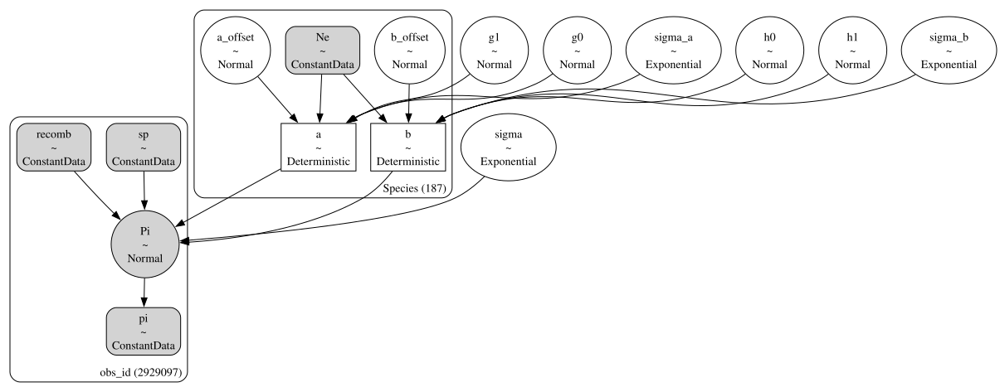

In [37]:
pm.model_to_graphviz(hierarchical_log_scaled_ne_cmpermb_model)

In [63]:
with hierarchical_log_scaled_ne_cmpermb_model:
    idata = pm.sample_prior_predictive(samples=200)

Sampling: [Pi, a_offset, b_offset, g0, g1, h0, h1, sigma, sigma_a, sigma_b]


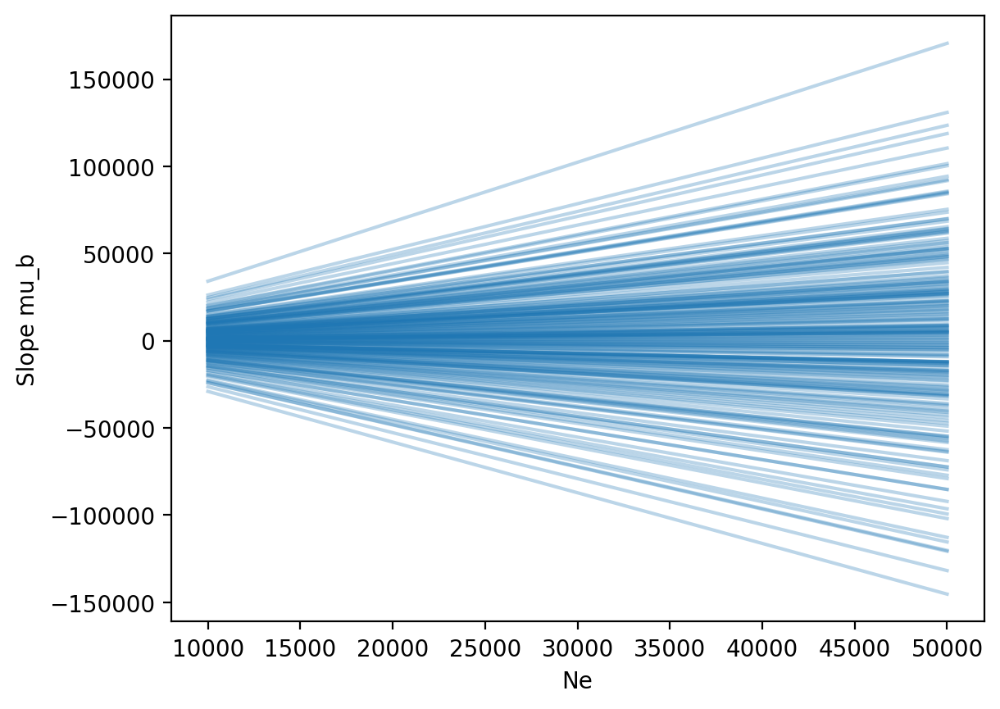

In [66]:
_, ax = plt.subplots()

Ne = xr.DataArray(np.linspace(10000, 50000, 200), dims=["plot_dim"])
prior = idata.prior
mu_b = prior["h0"] + prior["h1"] * Ne

ax.plot(Ne, mu_b.stack(sample=("chain", "draw")), c="C0", alpha=0.3)
ax.set_xlabel("Ne")
ax.set_ylabel("Slope mu_b") ;

<Axes: xlabel='Pi / Pi'>

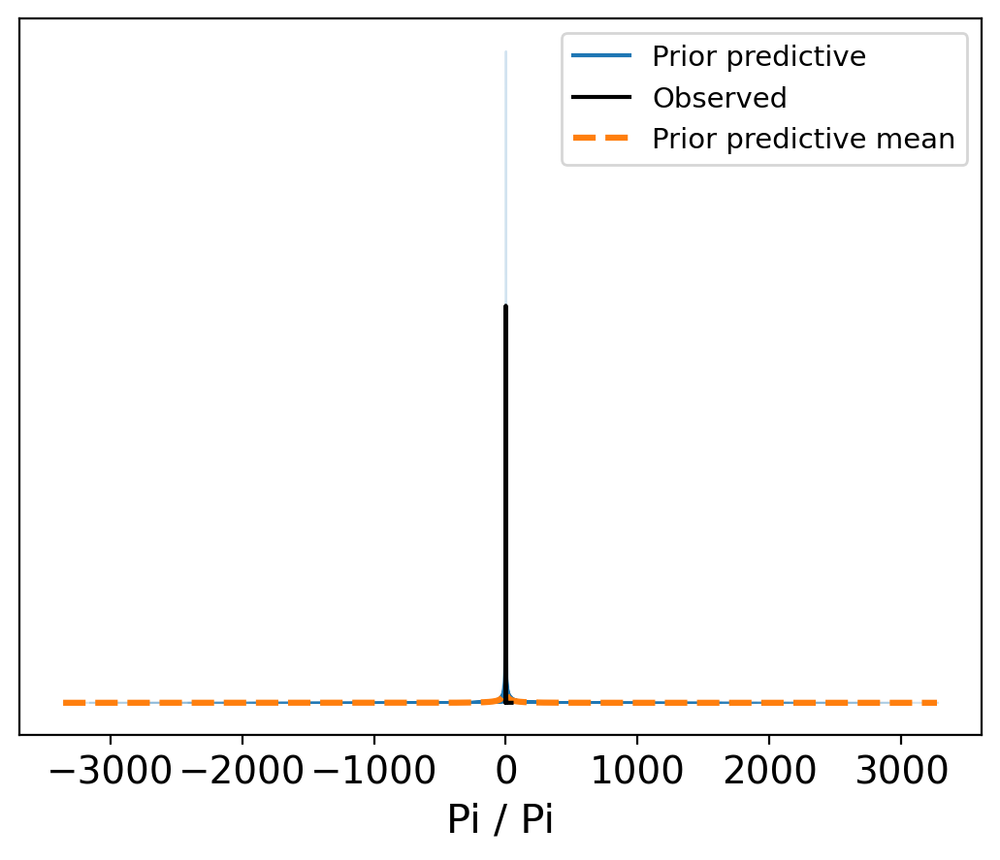

In [39]:
az.plot_ppc(idata, group='prior') ;

In [22]:
trace_file2 = 'hierarchical_log_scaled_ne_cmpermb_model_18_12_2023.nc'
if os.path.exists(trace_file2):
    with hierarchical_log_scaled_ne_cmpermb_model:
         hierarchical_model_log_idata = az.from_netcdf(trace_file2)
else:
    with hierarchical_log_scaled_ne_cmpermb_model:
        hierarchical_model_log_idata = pm.sample(1000, 
                                                 target_accept=0.95, return_inferencedata=True,
                                 progressbar=True, cores=8, chains=8)
        hierarchical_model_log_idata.to_netcdf(trace_file2)

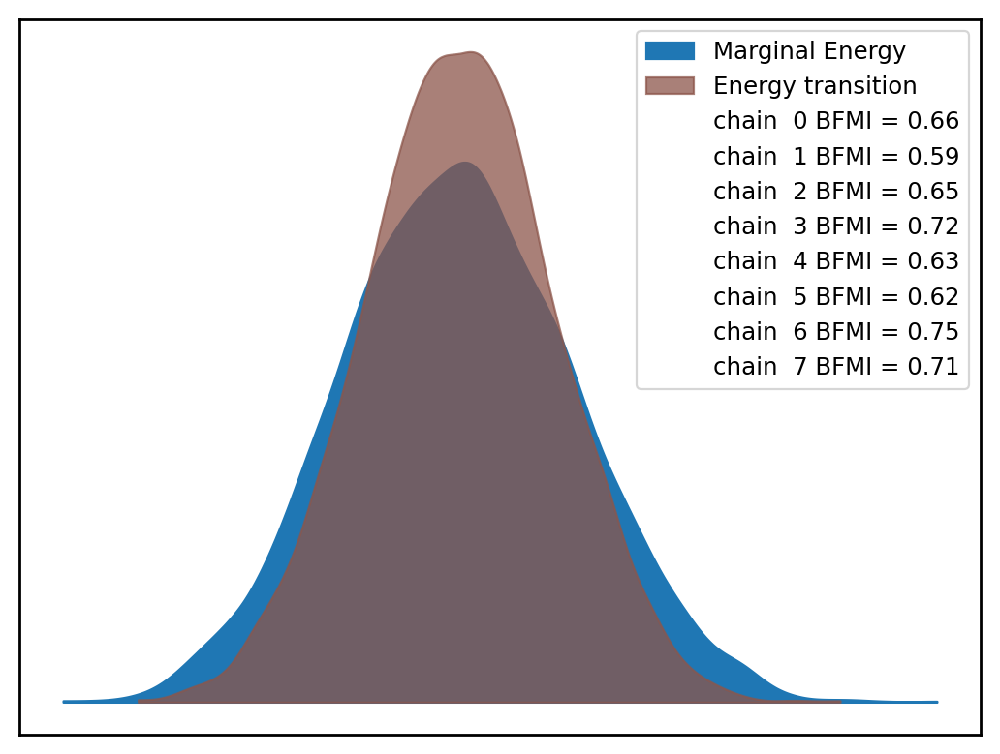

In [83]:
az.plot_energy(hierarchical_model_log_idata);

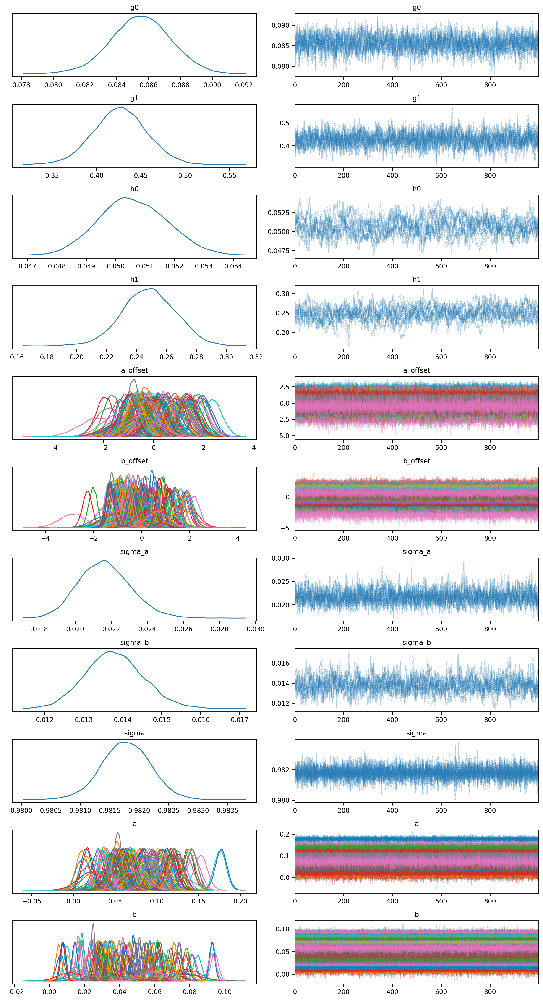

In [104]:
az.plot_trace(hierarchical_model_log_idata, combined=True)
plt.tight_layout()

In [26]:
hierarchical_model_log_idata.groups()

['posterior', 'sample_stats', 'observed_data', 'constant_data']

In [ ]:
with hierarchical_log_scaled_ne_cmpermb_model:
    pm.sample_posterior_predictive(hierarchical_model_log_idata, extend_inferencedata=True)

Sampling: [Pi]


In [ ]:
az.plot_ppc(idata)

In [ ]:
az.plot_bpv(idata)

In [34]:
hierarchical_model_log_idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [36]:
hierarchical_model_log_idata.groups()

['posterior', 'sample_stats', 'observed_data', 'constant_data']

In [67]:
az.style.use('default')

The reference value is outside of the posterior. This translate into infinite support for H1, which is most likely an overstatement.


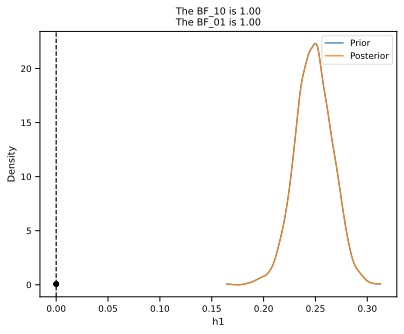

In [74]:
sns.set_context('paper')
az.plot_bf(hierarchical_model_log_idata.posterior, var_name="h1") ;
#sns.despine()

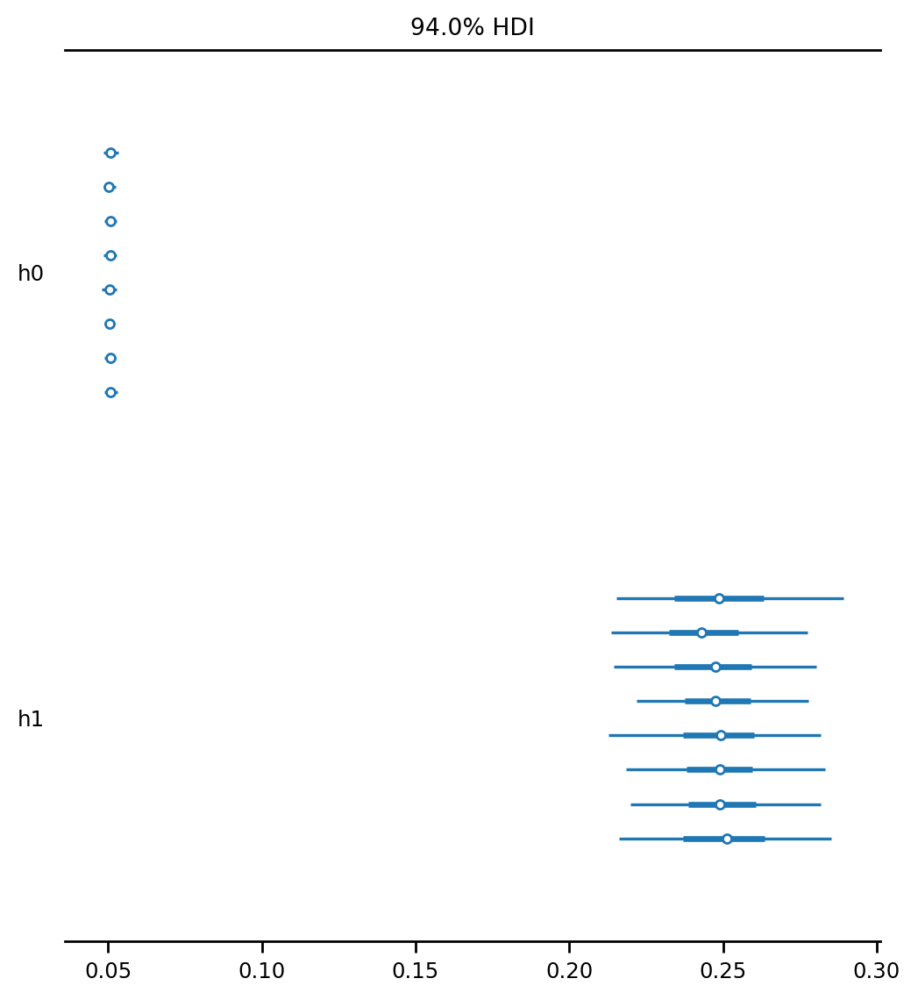

In [84]:
az.plot_forest(hierarchical_model_log_idata.posterior, var_names=['h0', 'h1']) ;

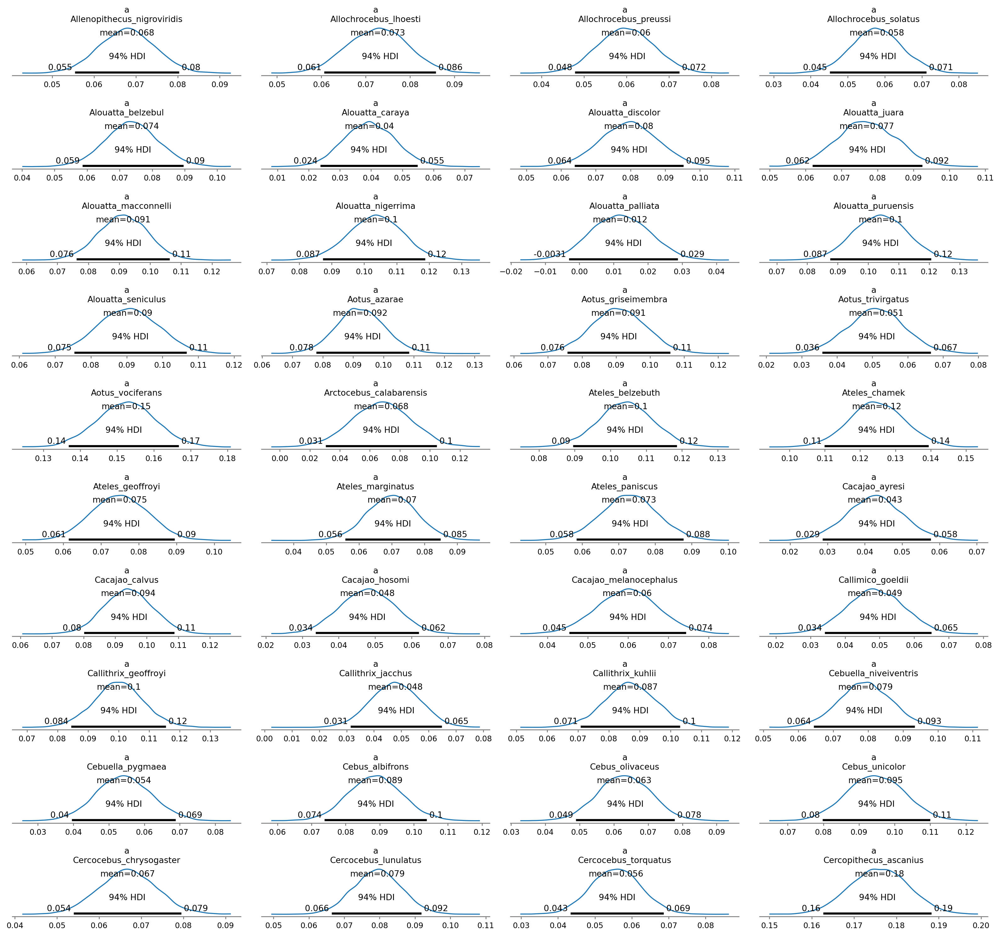

In [113]:
az.plot_posterior(hierarchical_model_log_idata, var_names=['a', 'b'], figsize=(16, 15))
plt.tight_layout()

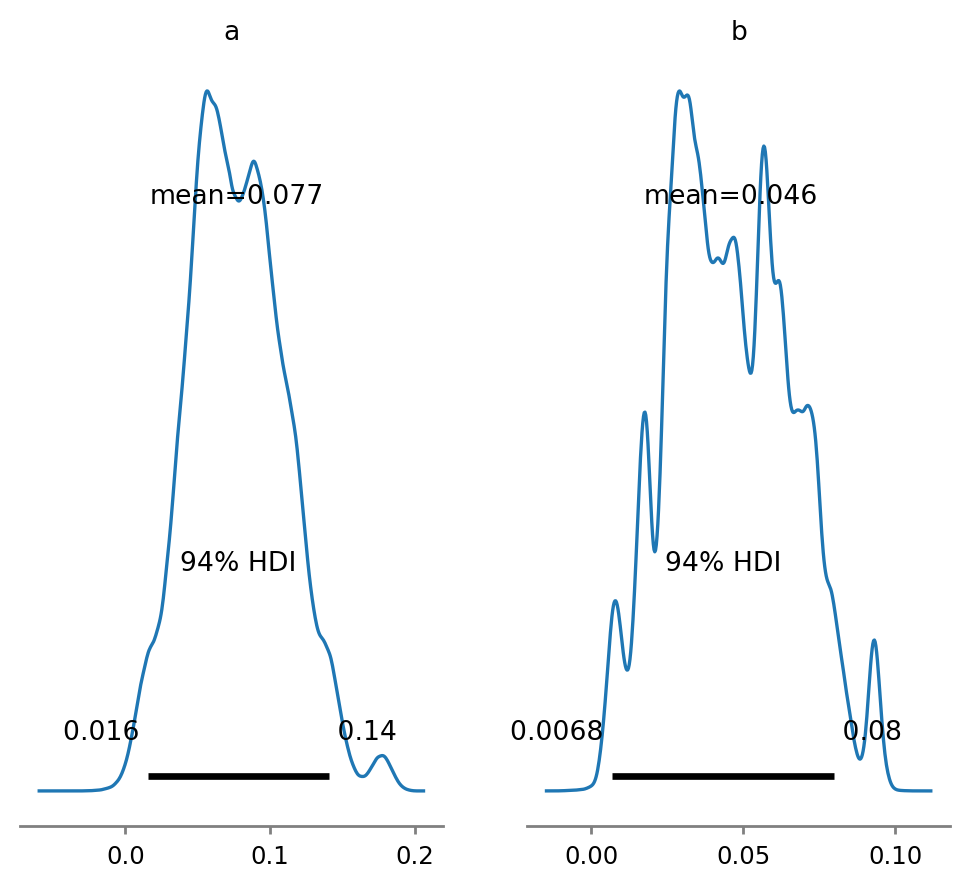

In [107]:
az.plot_posterior(hierarchical_model_log_idata, var_names=['a', 'b'], combine_dims={'Species'}, figsize=(6, 5)) ;

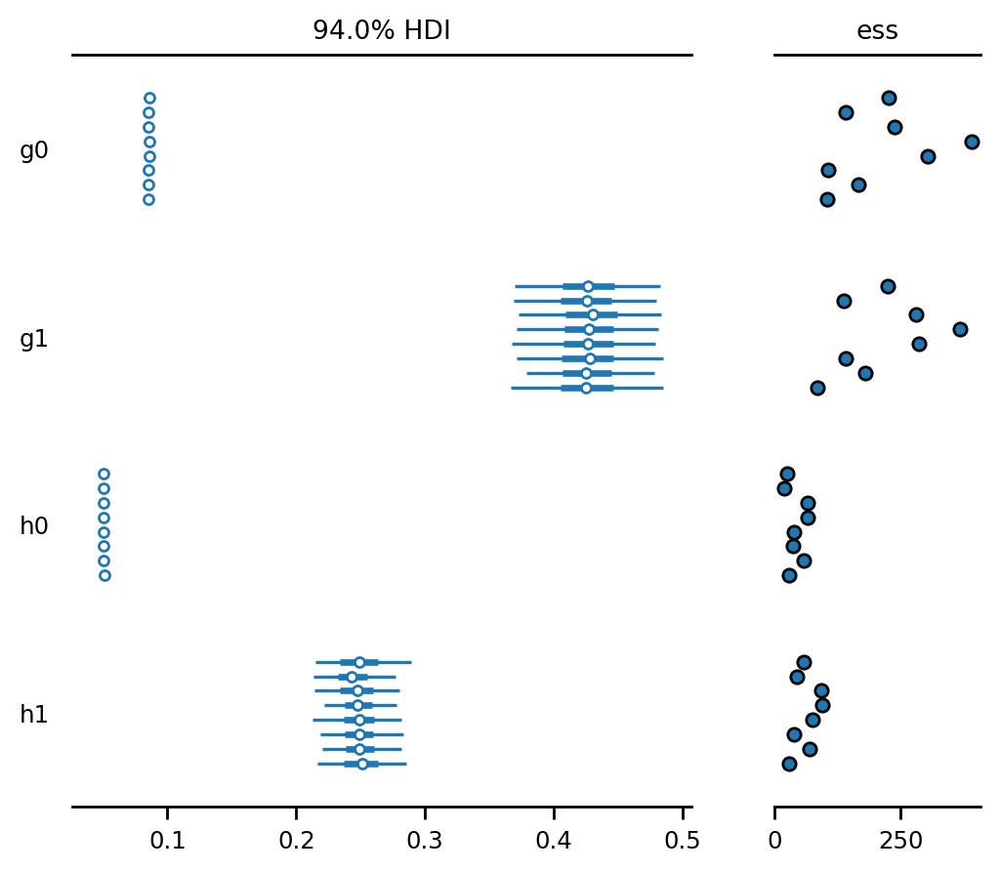

In [94]:
az.plot_forest(hierarchical_model_log_idata.posterior, var_names=['g0', 'g1', 'h0', 'h1'], ess=True, figsize=(6, 5)) ;



In [103]:
az.plot_forest(hierarchical_model_log_idata.posterior, var_names=['b'], ess=True, figsize=(15, 100)) ;

# compare models

In [ ]:
with hierarchical_log_scaled_ne_cmpermb_model:
    pm.compute_log_likelihood(hierarchical_model_log_idata)

In [ ]:
with hierarchical_model:
    pm.compute_log_likelihood(hierarchical_model_idata)

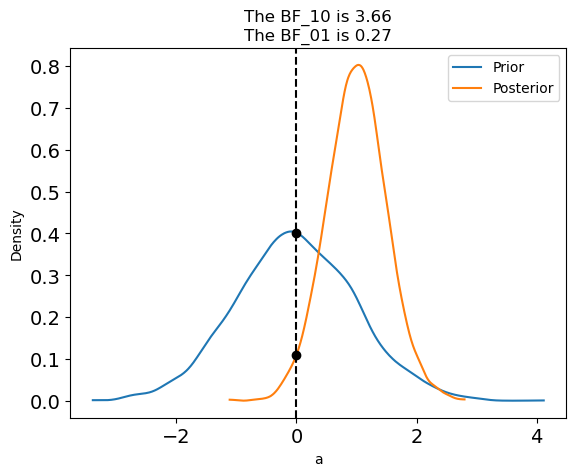

In [23]:
# import matplotlib.pyplot as plt
# import numpy as np
# import arviz as az

idata = az.from_dict(
    posterior={"a": np.random.normal(1, 0.5, 5000)}, prior={"a": np.random.normal(0, 1, 5000)}
)

az.plot_bf(idata, var_name="a", ref_val=0)
plt.show()

In [ ]:
import arviz as az
import numpy as np
import timeit
import dask

from arviz.utils import conditional_jit, Dask

In [ ]:
# optional imports
from dask.distributed import Client
from dask.diagnostics import ResourceProfiler

from bokeh.resources import INLINE
import bokeh.io

bokeh.io.output_notebook(INLINE)

%reload_ext memory_profiler

> ResourceProfiler() and Client are optional. They are only used for the visualizing and profiling the dask enabled methods. ArviZ-Dask integration can be used without using these objects.

In [ ]:
client = Client(threads_per_worker=4, n_workers=1, memory_limit="1.2GB")
client

In [ ]:
array_size = 250_000_000

In [ ]:
%%memit 
data = np.random.randn(array_size)
np.var(data, ddof=1)
del data

In [ ]:
%memit data = dask.array.random.normal(size=array_size, chunks="auto")
data

In [ ]:
var = dask.array.var(data, ddof=1)
var.visualize()

In [ ]:
with ResourceProfiler(dt=0.25) as rprof:
    var.compute()

rprof.visualize();